In [1]:
# ============================================================
# LOAN APPROVAL PREDICTION SYSTEM
# Data Science Internship - Phase 2
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import joblib

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [5]:
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("../data/train.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (3192, 14)


,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,Approved


In [9]:
print(df.columns.tolist())
print(df.shape)

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Employment_Status', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Term', 'Credit_History', 'Property_Area', 'Age', 'Loan_Status']
(3192, 14)


In [11]:
# ============================================================
# DATASET INSPECTION
# ============================================================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nLoan Status Distribution:")
print(df["Loan_Status"].value_counts())

Dataset Shape: (3192, 14)

Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Employment_Status', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Term', 'Credit_History', 'Property_Area', 'Age', 'Loan_Status']

Data Types:
Loan_ID                object
Gender                 object
Married                object
Dependents              int64
Education              object
Employment_Status      object
Applicant_Income      float64
Coapplicant_Income    float64
Loan_Amount           float64
Loan_Term               int64
Credit_History          int64
Property_Area          object
Age                   float64
Loan_Status            object
dtype: object

Missing Values:
Loan_ID                0
Gender                77
Married               66
Dependents             0
Education             66
Employment_Status     56
Applicant_Income      35
Coapplicant_Income     0
Loan_Amount           41
Loan_Term              0
Credit_History         0
Property_Are

In [13]:
# ============================================================
# DATA CLEANING
# ============================================================

# Remove duplicate records
df = df.drop_duplicates().copy()

# Clean text columns
text_columns = [
    "Gender",
    "Married",
    "Education",
    "Employment_Status",
    "Property_Area",
    "Loan_Status"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

# Convert numerical columns
numeric_columns = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Loan_Term",
    "Credit_History",
    "Age"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Dependents may contain values such as "3+"
df["Dependents"] = (
    df["Dependents"]
    .astype(str)
    .str.replace("+", "", regex=False)
)

df["Dependents"] = pd.to_numeric(
    df["Dependents"],
    errors="coerce"
)

print("Dataset Shape After Cleaning:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicates After Cleaning:")
print(df.duplicated().sum())

Dataset Shape After Cleaning: (3192, 14)

Missing Values After Cleaning:
Loan_ID                0
Gender                 0
Married                0
Dependents             0
Education              0
Employment_Status      0
Applicant_Income      35
Coapplicant_Income     0
Loan_Amount           41
Loan_Term              0
Credit_History         0
Property_Area          0
Age                    0
Loan_Status            0
dtype: int64

Duplicates After Cleaning:
0


In [15]:
# ============================================================
# LOAN STATUS VALUES
# ============================================================

print(df["Loan_Status"].value_counts())
print("\nUnique Loan Status Values:")
print(df["Loan_Status"].unique())

Loan_Status
Approved    1596
Rejected    1596
Name: count, dtype: int64

Unique Loan Status Values:
['Approved' 'Rejected']


In [17]:
# ============================================================
# TARGET VARIABLE STANDARDIZATION
# ============================================================

df["Loan_Status"] = (
    df["Loan_Status"]
    .astype(str)
    .str.strip()
)

df["Loan_Status"] = df["Loan_Status"].replace({
    "Y": "Approved",
    "N": "Rejected",
    "Yes": "Approved",
    "No": "Rejected",
    "YES": "Approved",
    "NO": "Rejected",
    "1": "Approved",
    "0": "Rejected"
})

print(df["Loan_Status"].value_counts())

Loan_Status
Approved    1596
Rejected    1596
Name: count, dtype: int64


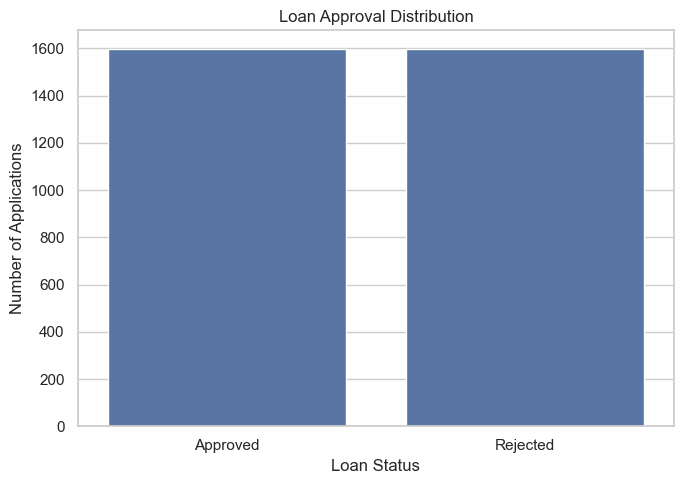

In [19]:
# ============================================================
# LOAN APPROVAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Loan_Status"
)

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.tight_layout()
plt.show()

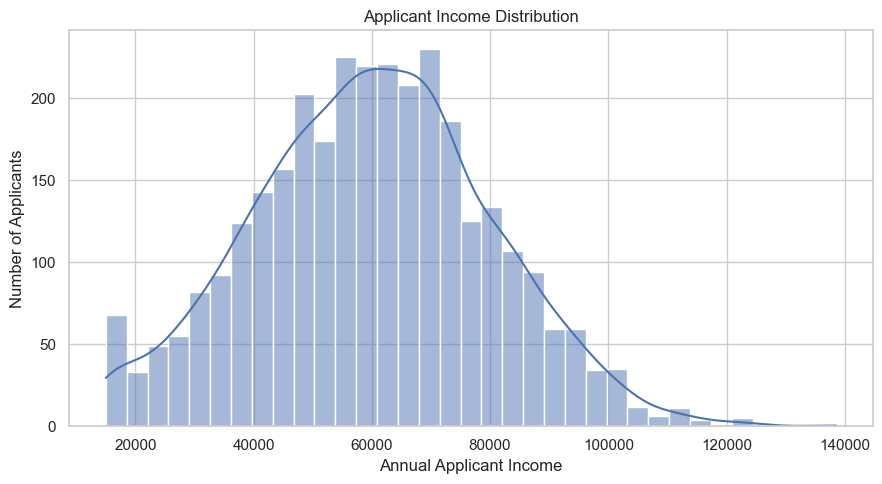

In [21]:
# ============================================================
# INCOME DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Applicant_Income",
    kde=True
)

plt.title("Applicant Income Distribution")
plt.xlabel("Annual Applicant Income")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

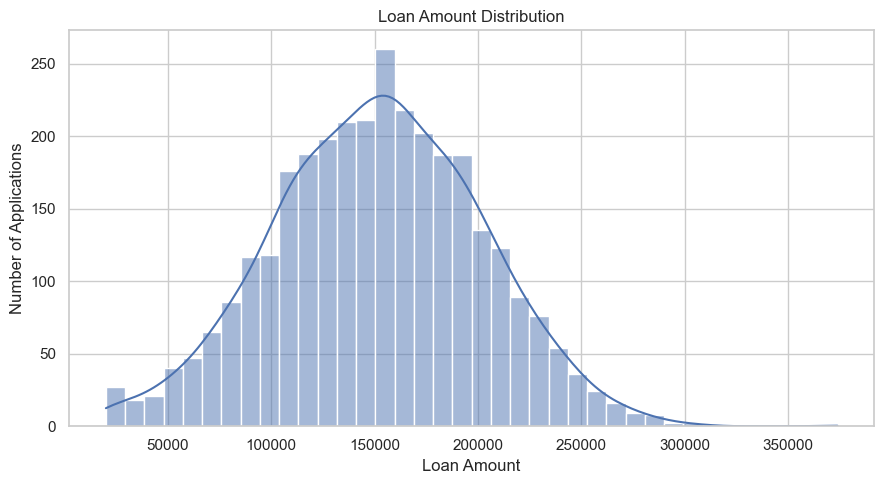

In [23]:
# ============================================================
# LOAN AMOUNT ANALYSIS
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Loan_Amount",
    kde=True
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Applications")

plt.tight_layout()
plt.show()

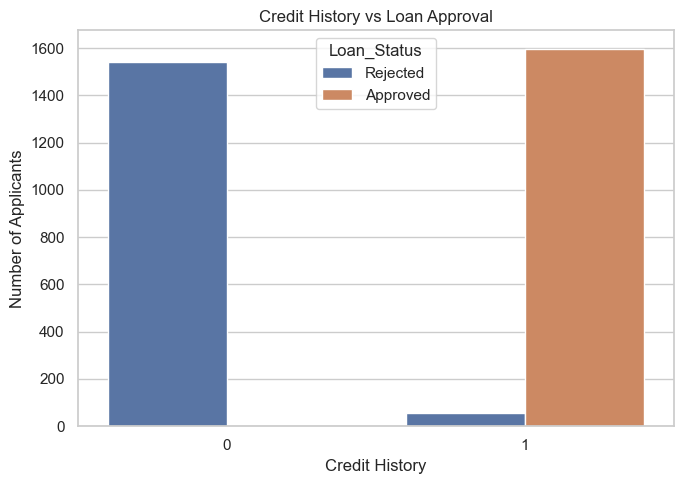

In [25]:
# ============================================================
# CREDIT HISTORY ANALYSIS
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Credit_History",
    hue="Loan_Status"
)

plt.title("Credit History vs Loan Approval")
plt.xlabel("Credit History")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

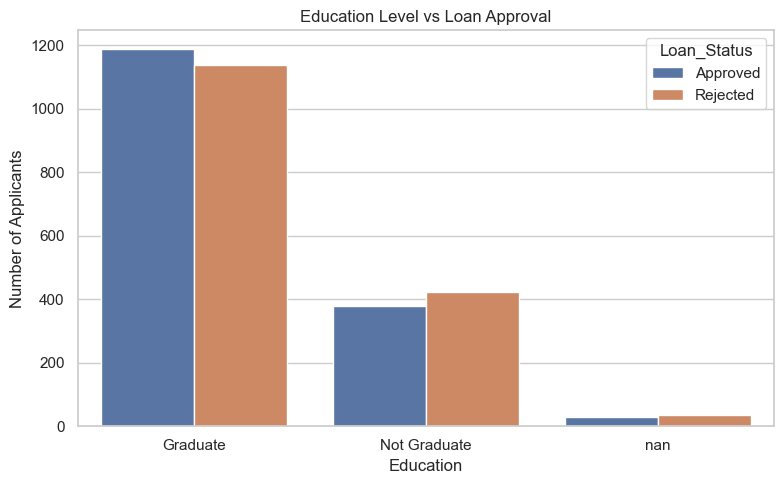

In [27]:
# ============================================================
# EDUCATION VS APPROVAL
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Education",
    hue="Loan_Status"
)

plt.title("Education Level vs Loan Approval")
plt.xlabel("Education")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

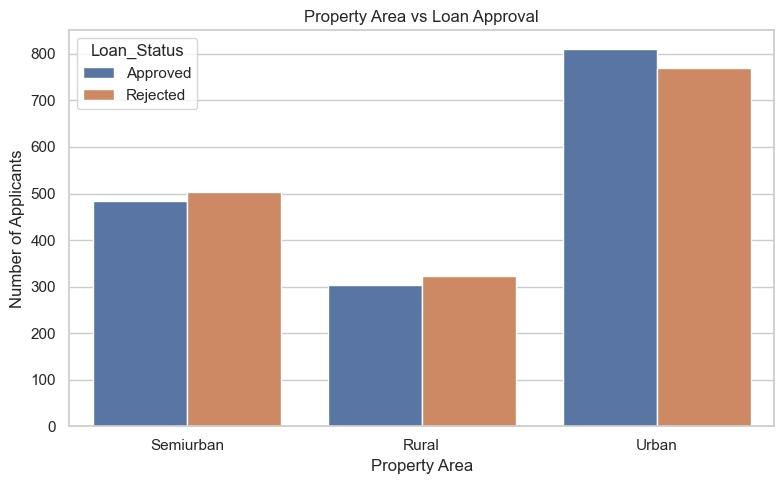

In [29]:
# ============================================================
# PROPERTY AREA VS APPROVAL
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Property_Area",
    hue="Loan_Status"
)

plt.title("Property Area vs Loan Approval")
plt.xlabel("Property Area")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

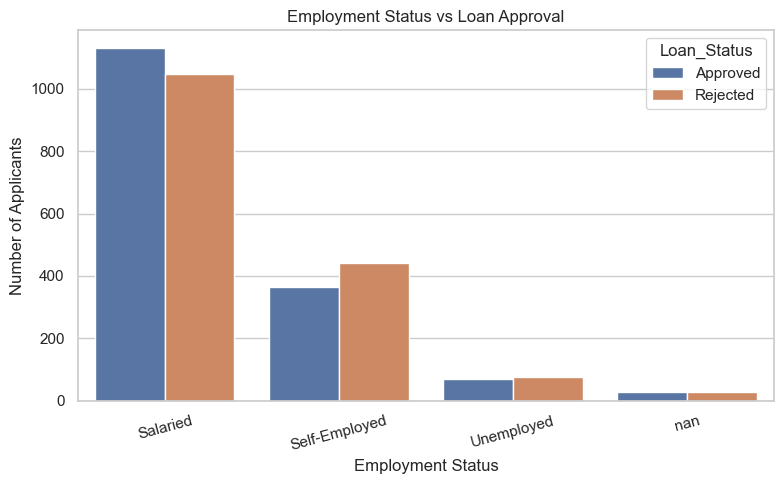

In [31]:
# ============================================================
# EMPLOYMENT STATUS VS APPROVAL
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Employment_Status",
    hue="Loan_Status"
)

plt.title("Employment Status vs Loan Approval")
plt.xlabel("Employment Status")
plt.ylabel("Number of Applicants")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

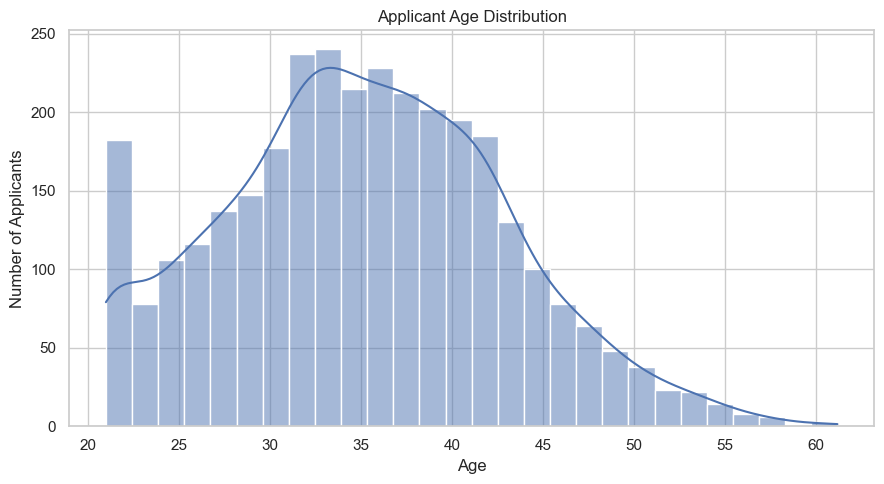

In [33]:
# ============================================================
# AGE DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    kde=True
)

plt.title("Applicant Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")

plt.tight_layout()
plt.show()

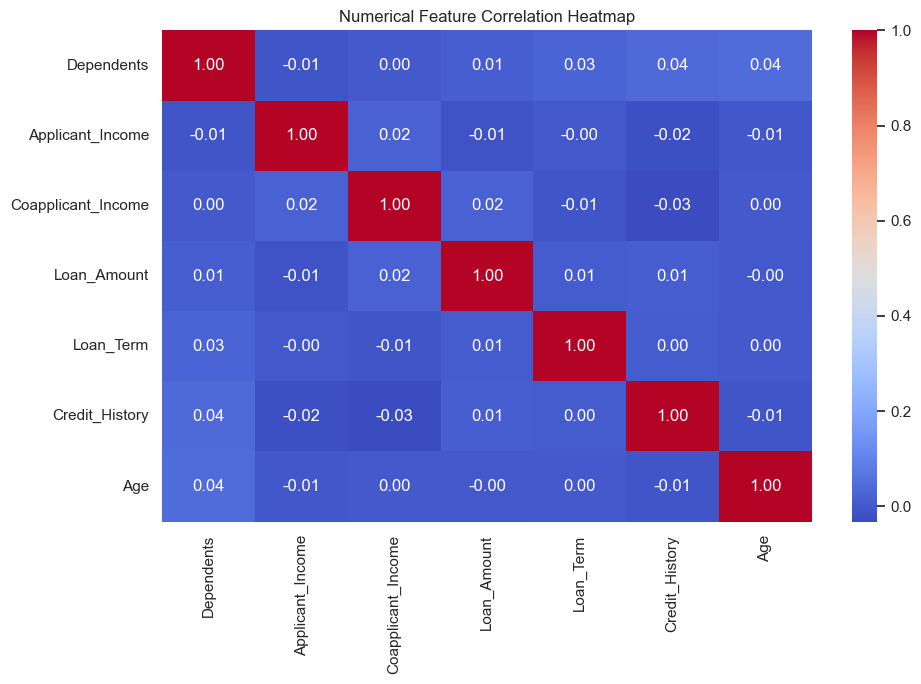

In [35]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

numeric_df = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

In [37]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

df["Total_Income"] = (
    df["Applicant_Income"].fillna(0)
    +
    df["Coapplicant_Income"].fillna(0)
)

df["Loan_to_Income_Ratio"] = (
    df["Loan_Amount"] /
    df["Total_Income"].replace(0, np.nan)
)

print(
    df[
        [
            "Applicant_Income",
            "Coapplicant_Income",
            "Total_Income",
            "Loan_Amount",
            "Loan_to_Income_Ratio"
        ]
    ].head()
)

   Applicant_Income  Coapplicant_Income   Total_Income    Loan_Amount  \
0      34473.911669        13914.721574   48388.633244  240732.458366   
1      59718.020682        18720.814787   78438.835469  122547.278442   
2     106981.515734         2229.154377  109210.670111  140550.937774   
3      43205.563156        35578.111771   78783.674927  146135.738127   
4      62526.283990        20212.157912   82738.441902  203408.051744   

   Loan_to_Income_Ratio  
0              4.974979  
1              1.562329  
2              1.286971  
3              1.854899  
4              2.458447  


In [39]:
# ============================================================
# PREPARE FEATURES AND TARGET
# ============================================================

X = df.drop(
    columns=["Loan_Status", "Loan_ID"]
)

y = df["Loan_Status"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Feature Shape: (3192, 14)
Target Shape: (3192,)

Target Distribution:
Loan_Status
Approved    1596
Rejected    1596
Name: count, dtype: int64


In [41]:
# ============================================================
# FEATURE TYPES
# ============================================================

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Dependents', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Term', 'Credit_History', 'Age', 'Total_Income', 'Loan_to_Income_Ratio']

Categorical Features:
['Gender', 'Married', 'Education', 'Employment_Status', 'Property_Area']


In [43]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [45]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 2553
Testing Samples: 639


In [47]:
# ============================================================
# CLASSIFICATION MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}

trained_models = {}

for name, classifier in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                classifier
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

    print(
        f"{name} trained successfully."
    )

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
SVM trained successfully.


In [49]:
# ============================================================
# MODEL EVALUATION
# ============================================================

results = []

for name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

performance = pd.DataFrame(results)

performance = performance.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

performance

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982786,0.983358,0.982786,0.982780
1,Decision Tree,0.978091,0.978390,0.978091,0.978087
2,Random Forest,0.974961,0.975873,0.974961,0.974948
3,SVM,0.974961,0.976153,0.974961,0.974944


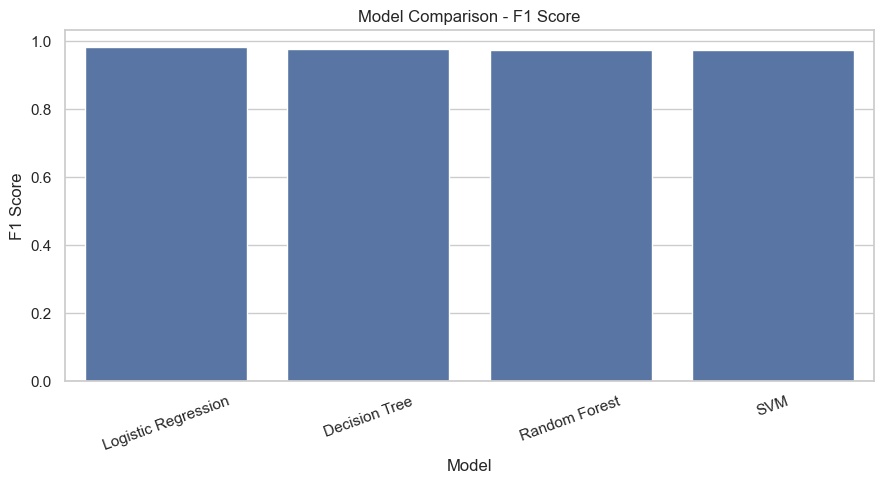

In [51]:
# ============================================================
# MODEL COMPARISON
# ============================================================

plt.figure(figsize=(9, 5))

sns.barplot(
    data=performance,
    x="Model",
    y="F1 Score"
)

plt.title("Model Comparison - F1 Score")
plt.xlabel("Model")
plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [53]:
# ============================================================
# BEST MODEL
# ============================================================

best_model_name = performance.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("Best Model:", best_model_name)

Best Model: Logistic Regression


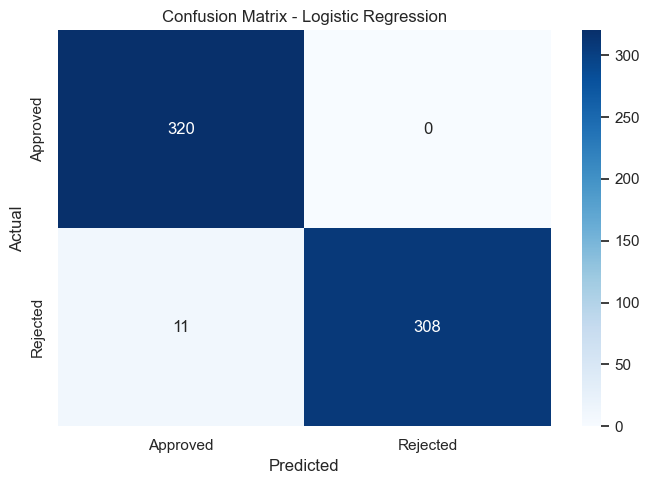

In [55]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

y_pred_best = best_model.predict(
    X_test
)

class_labels = best_model.classes_

cm = confusion_matrix(
    y_test,
    y_pred_best,
    labels=class_labels
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

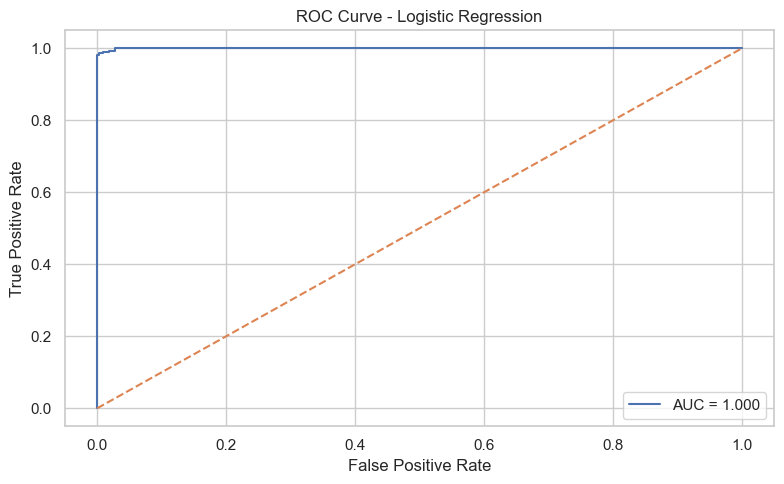

In [57]:
# ============================================================
# ROC CURVE
# ============================================================

if hasattr(best_model, "predict_proba"):

    probabilities = best_model.predict_proba(
        X_test
    )

    positive_class = "Approved"

    class_index = list(
        best_model.classes_
    ).index(positive_class)

    y_probability = probabilities[
        :, class_index
    ]

    y_test_binary = (
        y_test == positive_class
    ).astype(int)

    fpr, tpr, _ = roc_curve(
        y_test_binary,
        y_probability
    )

    auc_score = roc_auc_score(
        y_test_binary,
        y_probability
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {auc_score:.3f}"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--"
    )

    plt.title(
        f"ROC Curve - {best_model_name}"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.legend()

    plt.tight_layout()
    plt.show()

In [59]:
# ============================================================
# SAVE MODEL FILES
# ============================================================

joblib.dump(
    best_model,
    "../models/loan_approval_model.pkl"
)

performance.to_csv(
    "../models/model_performance.csv",
    index=False
)

joblib.dump(
    list(X.columns),
    "../models/feature_columns.pkl"
)

print("Model saved successfully.")
print("Performance file saved successfully.")
print("Feature columns saved successfully.")

Model saved successfully.
Performance file saved successfully.
Feature columns saved successfully.


In [65]:
# ============================================================
# BUSINESS INSIGHTS
# ============================================================

approval_rate = (
    df["Loan_Status"]
    .eq("Approved")
    .mean()
    * 100
)

print(
    f"Overall Loan Approval Rate: "
    f"{approval_rate:.2f}%"
)

print("\nApproval Rate by Education:")

education_approval = (
    df.groupby("Education")[
        "Loan_Status"
    ]
    .apply(
        lambda x:
        (x == "Approved").mean() * 100
    )
)

print(
    education_approval.round(2)
)

print("\nApproval Rate by Property Area:")

property_approval = (
    df.groupby("Property_Area")[
        "Loan_Status"
    ]
    .apply(
        lambda x:
        (x == "Approved").mean() * 100
    )
)

print(
    property_approval.round(2)
)

print("\nApproval Rate by Employment Status:")

employment_approval = (
    df.groupby("Employment_Status")[
        "Loan_Status"
    ]
    .apply(
        lambda x:
        (x == "Approved").mean() * 100
    )
)

print(
    employment_approval.round(2)
)

Overall Loan Approval Rate: 50.00%

Approval Rate by Education:
Education
Graduate        51.10
Not Graduate    47.20
nan             45.45
Name: Loan_Status, dtype: float64

Approval Rate by Property Area:
Property_Area
Rural        48.40
Semiurban    48.94
Urban        51.30
Name: Loan_Status, dtype: float64

Approval Rate by Employment Status:
Employment_Status
Salaried         51.88
Self-Employed    45.24
Unemployed       47.65
nan              51.79
Name: Loan_Status, dtype: float64


In [63]:
# ============================================================
# SAVE CLEANED DATASET
# ============================================================

df.to_csv(
    "../data/cleaned_loan_approval_dataset.csv",
    index=False
)

print(
    "Cleaned dataset saved successfully."
)

Cleaned dataset saved successfully.


In [67]:
print(df["Loan_Status"].value_counts())
print(df["Loan_Status"].unique())

Loan_Status
Approved    1596
Rejected    1596
Name: count, dtype: int64
['Approved' 'Rejected']
